In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def load_network(file_path):
    #Load the network data from text file.
    return pd.read_csv(file_path, sep="\t", header=None, names=["Node1", "Node2", "Cost"])

In [3]:
def initialize_population(population_size, num_links):
    #Initialize a population of chromosomes.
    return np.random.randint(2, size=(population_size, num_links))

In [4]:
def fitness(chromosome, cost_matrix, total_cost):
    #Calculate the fitness of a chromosome.
    network_cost = np.sum(chromosome * cost_matrix)
    return 1 - (network_cost / total_cost)

In [5]:
def tournament_selection(population, fitness_scores, k):
    #Perform tournament selection.
    selected = np.random.choice(len(population), k)
    best_idx = selected[np.argmax([fitness_scores[i] for i in selected])]
    return population[best_idx]

In [6]:
def two_point_crossover(parent1, parent2):
    #Perform two-point crossover.
    size = len(parent1)
    point1, point2 = sorted(random.sample(range(size), 2))
    child1 = np.concatenate((parent1[:point1], parent2[point1:point2], parent1[point2:]))
    child2 = np.concatenate((parent2[:point1], parent1[point1:point2], parent2[point2:]))
    return child1, child2

In [7]:
def mutate(chromosome, mutation_rate):
    #Mutate a chromosome with the given mutation rate.
    for i in range(len(chromosome)):
        if random.random() < mutation_rate:
            chromosome[i] = 1 - chromosome[i]

In [8]:
def genetic_algorithm(cost_matrix, total_cost, params):

    population_size = params["POPULATION_SIZE"]
    crossover_rate = params["CROSSOVER_RATE"]
    mutation_rate = params["MUTATION_RATE"]
    max_generations = params["MAX_GENERATIONS"]

    population = initialize_population(population_size, len(cost_matrix))
    best_fitness = []
    avg_fitness = []

    for generation in range(max_generations):
        fitness_scores = [fitness(ind, cost_matrix, total_cost) for ind in population]
        next_population = []

        # Evolve population
        for _ in range(population_size // 2):
            parent1 = tournament_selection(population, fitness_scores, params["TOURNAMENT_SIZE"])
            parent2 = tournament_selection(population, fitness_scores, params["TOURNAMENT_SIZE"])
            if random.random() < crossover_rate:
                child1, child2 = two_point_crossover(parent1, parent2)
            else:
                child1, child2 = parent1, parent2
            mutate(child1, mutation_rate)
            mutate(child2, mutation_rate)
            next_population.extend([child1, child2])

        population = np.array(next_population)
        best_fitness.append(max(fitness_scores))
        avg_fitness.append(np.mean(fitness_scores))

    return best_fitness, avg_fitness

In [9]:
#Loads the network data and extracts the cost matrix.
network_data = load_network("network.txt")
cost_matrix = network_data["Cost"].values
total_cost = np.sum(cost_matrix)

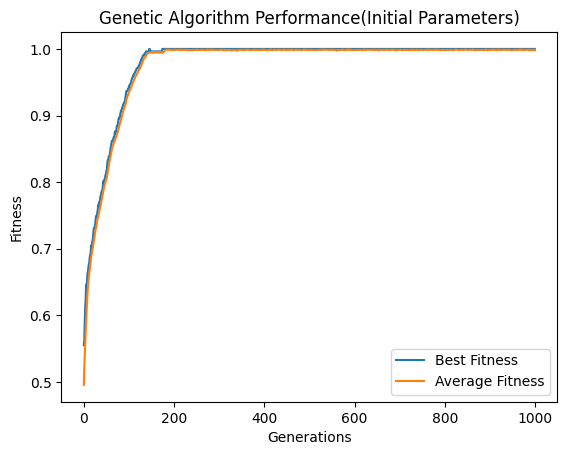

In [10]:
# initial parameters


    # GA Parameters
ga_params = {
    "POPULATION_SIZE": 100,
    "CROSSOVER_RATE": 0.7,
    "MUTATION_RATE": 0.001,
    "MAX_GENERATIONS": 1000,
    "TOURNAMENT_SIZE": 3
    }

# Run GA
best, avg = genetic_algorithm(cost_matrix, total_cost, ga_params)

# Plot results
plt.plot(best, label="Best Fitness")
plt.plot(avg, label="Average Fitness")
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.title("Genetic Algorithm Performance(Initial Parameters)")
plt.legend()
plt.show()

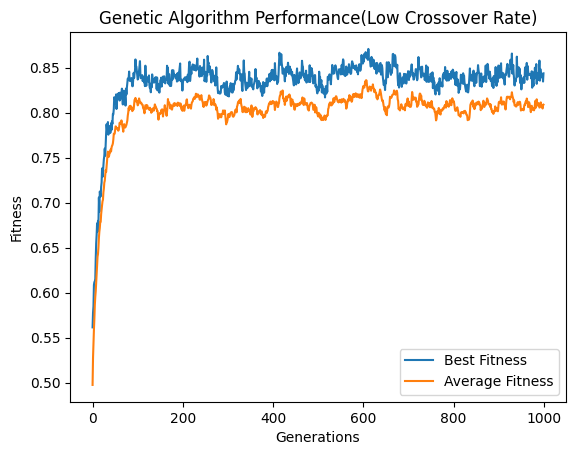

In [11]:
#Low CROSSOVER_RATE

# GA Parameters
ga_params = {
    "POPULATION_SIZE": 100,
    "CROSSOVER_RATE": 0.4,
    "MUTATION_RATE": 0.01,
    "MAX_GENERATIONS": 1000,
    "TOURNAMENT_SIZE": 5
    }

# Run GA
best, avg = genetic_algorithm(cost_matrix, total_cost, ga_params)

# Plot results
plt.plot(best, label="Best Fitness")
plt.plot(avg, label="Average Fitness")
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.title("Genetic Algorithm Performance(Low Crossover Rate)")
plt.legend()
plt.show()

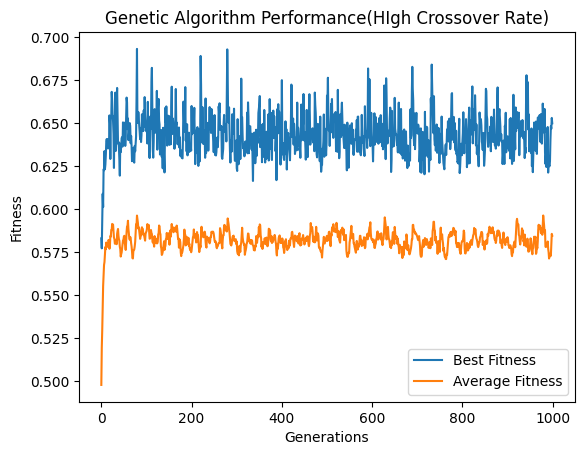

In [12]:
#HIgh CROSSOVER_RATE

# GA Parameters
ga_params = {
    "POPULATION_SIZE": 100,
    "CROSSOVER_RATE": 1,
    "MUTATION_RATE": 0.1,
    "MAX_GENERATIONS": 1000,
    "TOURNAMENT_SIZE": 3
    }

# Run GA
best, avg = genetic_algorithm(cost_matrix, total_cost, ga_params)

# Plot results
plt.plot(best, label="Best Fitness")
plt.plot(avg, label="Average Fitness")
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.title("Genetic Algorithm Performance(HIgh Crossover Rate)")
plt.legend()
plt.show()

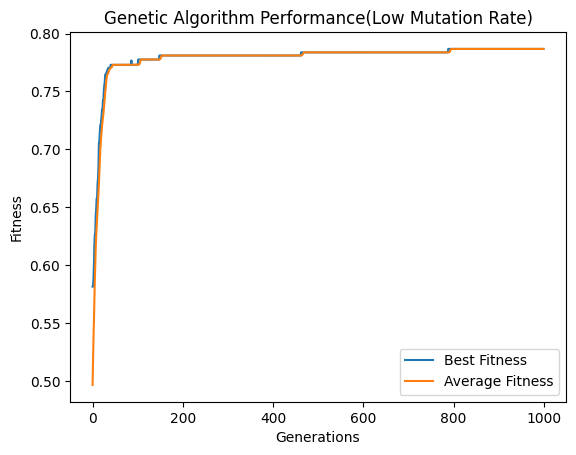

In [13]:
#Low MUTATION_RATE

    # GA Parameters
ga_params = {
    "POPULATION_SIZE": 100,
    "CROSSOVER_RATE": 0.7,
    "MUTATION_RATE": 0.000001,
    "MAX_GENERATIONS": 1000,
    "TOURNAMENT_SIZE": 3
    }

# Run GA
best, avg = genetic_algorithm(cost_matrix, total_cost, ga_params)

# Plot results
plt.plot(best, label="Best Fitness")
plt.plot(avg, label="Average Fitness")
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.title("Genetic Algorithm Performance(Low Mutation Rate)")
plt.legend()
plt.show()

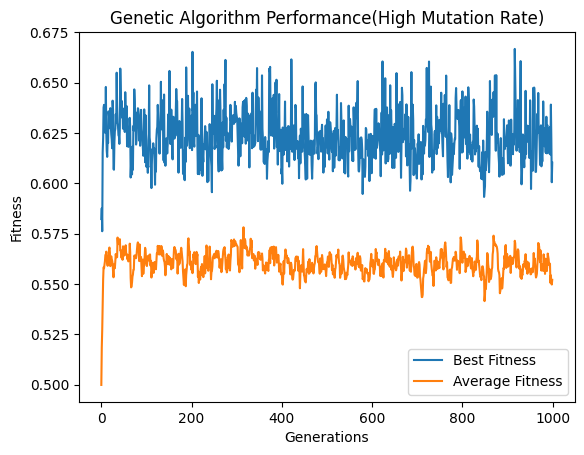

In [14]:
#High MUTATION_RATE

    # GA Parameters
ga_params = {
    "POPULATION_SIZE": 100,
    "CROSSOVER_RATE": 0.7,
    "MUTATION_RATE": 0.1,
    "MAX_GENERATIONS": 1000,
    "TOURNAMENT_SIZE": 3
    }

# Run GA
best, avg = genetic_algorithm(cost_matrix, total_cost, ga_params)

# Plot results
plt.plot(best, label="Best Fitness")
plt.plot(avg, label="Average Fitness")
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.title("Genetic Algorithm Performance(High Mutation Rate)")
plt.legend()
plt.show()

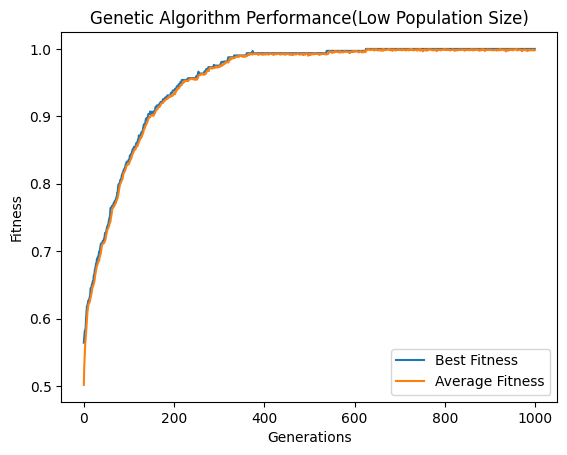

In [15]:
# Low POPULATION_SIZE

# GA Parameters
ga_params = {
    "POPULATION_SIZE": 25,
    "CROSSOVER_RATE": 0.7,
    "MUTATION_RATE": 0.001,
    "MAX_GENERATIONS": 1000,
    "TOURNAMENT_SIZE": 3
    }

# Run GA
best, avg = genetic_algorithm(cost_matrix, total_cost, ga_params)

# Plot results
plt.plot(best, label="Best Fitness")
plt.plot(avg, label="Average Fitness")
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.title("Genetic Algorithm Performance(Low Population Size)")
plt.legend()
plt.show()

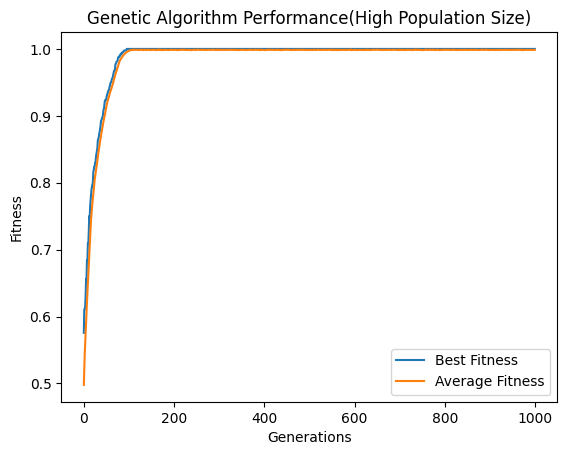

In [16]:
# High POPULATION_SIZE


# GA Parameters
ga_params = {
    "POPULATION_SIZE": 300,
    "CROSSOVER_RATE": 0.7,
    "MUTATION_RATE": 0.001,
    "MAX_GENERATIONS": 1000,
    "TOURNAMENT_SIZE": 3
    }

# Run GA
best, avg = genetic_algorithm(cost_matrix, total_cost, ga_params)

# Plot results
plt.plot(best, label="Best Fitness")
plt.plot(avg, label="Average Fitness")
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.title("Genetic Algorithm Performance(High Population Size)")
plt.legend()
plt.show()